In [22]:
import os
import cv2
import supervision as sv
from pathlib import Path
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm  # For progress bar
from ultralytics import YOLO


# Change these paths and run all cells
model = YOLO("/home/omtalmo/Olaf_TTK4265/TDT4265-Snow-pole-detection/yolov12/yolov12/runs/detect/train3/weights/best.pt")
dataset_path = "/home/omtalmo/Olaf_TTK4265/Poles/rgb"
output_dir = "/home/omtalmo/Olaf_TTK4265/TDT4265-Snow-pole-detection/results"

### Run inference on all images and save in output_dir

Processing 46 test images...


SupervisionWarnings: BoundingBoxAnnotator is deprecated: `BoundingBoxAnnotator` is deprecated and has been renamed to `BoxAnnotator`. `BoundingBoxAnnotator` will be removed in supervision-0.26.0.


  0%|          | 0/46 [00:00<?, ?it/s]


0: 416x640 2 poles, 4.6ms
Speed: 1.2ms preprocess, 4.6ms inference, 0.5ms postprocess per image at shape (1, 3, 416, 640)

0: 416x640 (no detections), 5.8ms
Speed: 1.2ms preprocess, 5.8ms inference, 0.3ms postprocess per image at shape (1, 3, 416, 640)

0: 96x640 (no detections), 6.4ms
Speed: 0.4ms preprocess, 6.4ms inference, 0.3ms postprocess per image at shape (1, 3, 96, 640)

0: 416x640 (no detections), 5.1ms
Speed: 1.0ms preprocess, 5.1ms inference, 0.3ms postprocess per image at shape (1, 3, 416, 640)

0: 416x640 1 pole, 5.2ms
Speed: 1.1ms preprocess, 5.2ms inference, 0.6ms postprocess per image at shape (1, 3, 416, 640)

0: 96x640 (no detections), 4.2ms
Speed: 0.3ms preprocess, 4.2ms inference, 0.2ms postprocess per image at shape (1, 3, 96, 640)

0: 416x640 3 poles, 5.3ms
Speed: 1.1ms preprocess, 5.3ms inference, 0.5ms postprocess per image at shape (1, 3, 416, 640)

0: 416x640 2 poles, 5.3ms
Speed: 1.0ms preprocess, 5.3ms inference, 0.5ms postprocess per image at shape (1, 3,

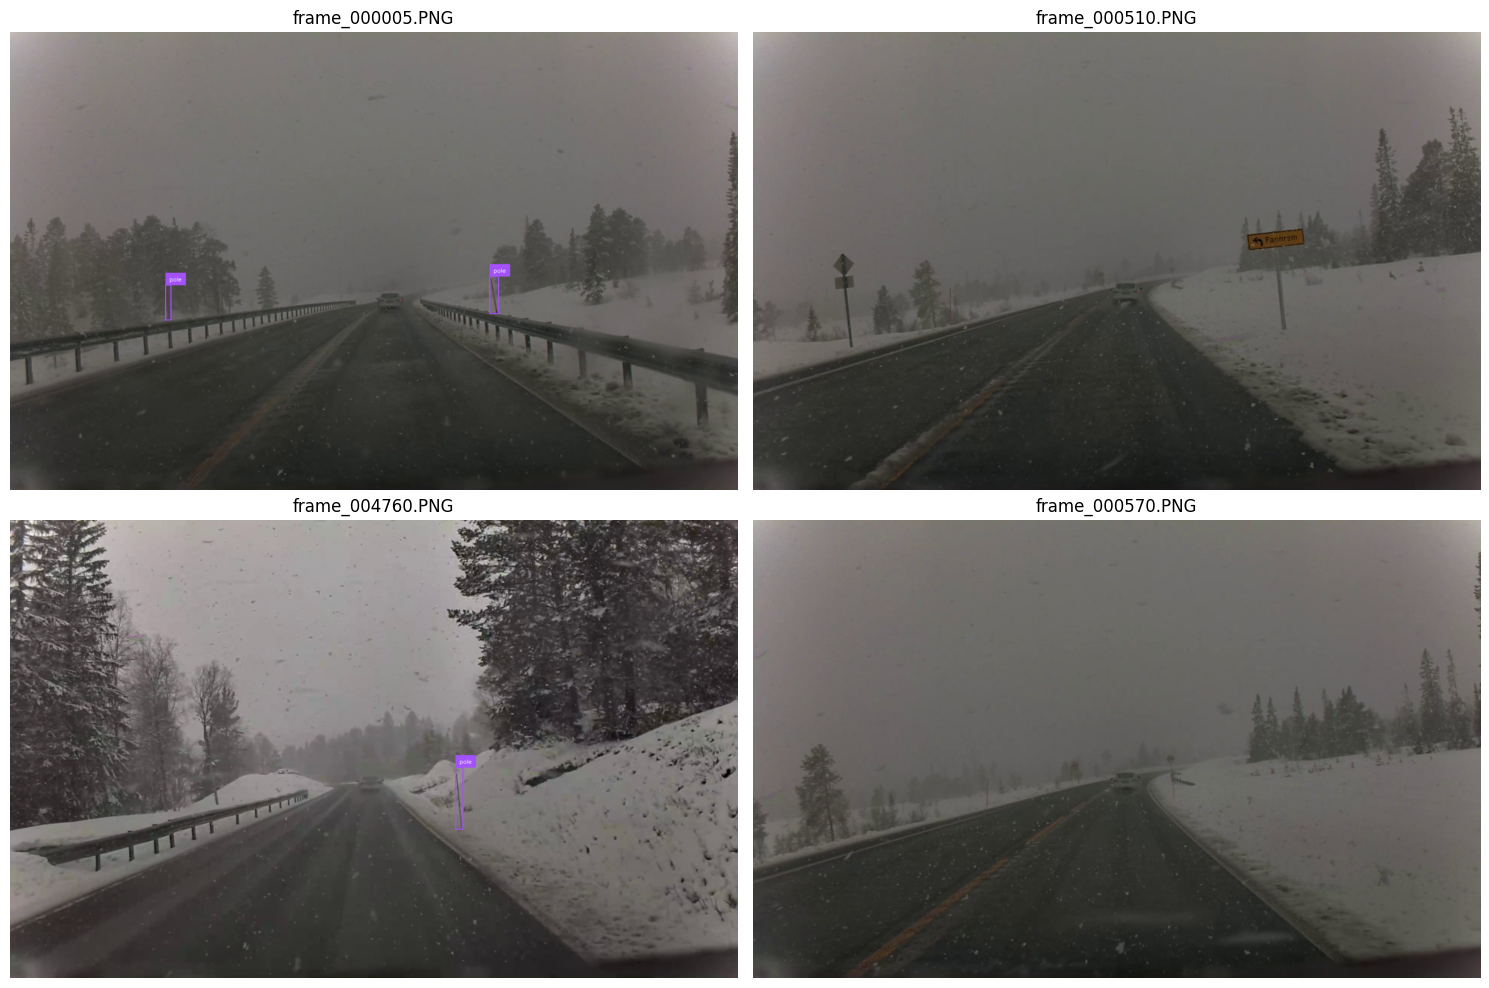

Processed 197 images
Results saved to: /home/edvarsa/pole_detection/Poles/TDT4265-Snow-pole-detection/results


In [23]:
# Find test images with case-insensitive extension matching
test_image_dir = f"{dataset_path}/test"
test_images = []
for img in os.listdir(test_image_dir):
    if img.upper().endswith('.PNG') or img.lower().endswith(('.png', '.jpg', '.jpeg')):
        test_images.append(os.path.join(test_image_dir, img))


os.makedirs(output_dir, exist_ok=True)

# Create annotators for visualization
bounding_box_annotator = sv.BoundingBoxAnnotator()
label_annotator = sv.LabelAnnotator()

# Process all test images
print(f"Processing {len(test_images)} test images...")
for image_path in tqdm(test_images):
    # Load and process the image
    image = cv2.imread(image_path)
    if image is None:
        print(f"Warning: Could not load {image_path}")
        continue
    
    # Make predictions
    results = model(image)[0]
    detections = sv.Detections.from_ultralytics(results).with_nms()
    
    # Apply annotations
    annotated_image = bounding_box_annotator.annotate(scene=image, detections=detections)
    annotated_image = label_annotator.annotate(scene=annotated_image, detections=detections)
    
    # Save the image result
    image_filename = Path(image_path).name
    output_path = os.path.join(output_dir, f"detection_{image_filename}")
    cv2.imwrite(output_path, annotated_image)

print(f"All results saved to {output_dir}")

# Optionally display a montage of some results (first 4 images)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, image_path in enumerate(test_images[:4]):
    if i >= 4:  # Limit to first 4 images
        break
        
    # Load the saved result
    image_filename = Path(image_path).name
    result_path = os.path.join(output_dir, f"detection_{image_filename}")
    
    if os.path.exists(result_path):
        result_img = cv2.imread(result_path)
        result_img_rgb = cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB)
        axes[i].imshow(result_img_rgb)
        axes[i].set_title(f"{image_filename}")
        axes[i].axis('off')
    
plt.tight_layout()
plt.show()

# Print summary 
print(f"Processed {len(test_images)} images")
print(f"Results saved to: {output_dir}")

### Visualize all rejected bounding boxes

Total potential boxes: 47460
Actual detected boxes (very low conf): 132
Final detections: 2


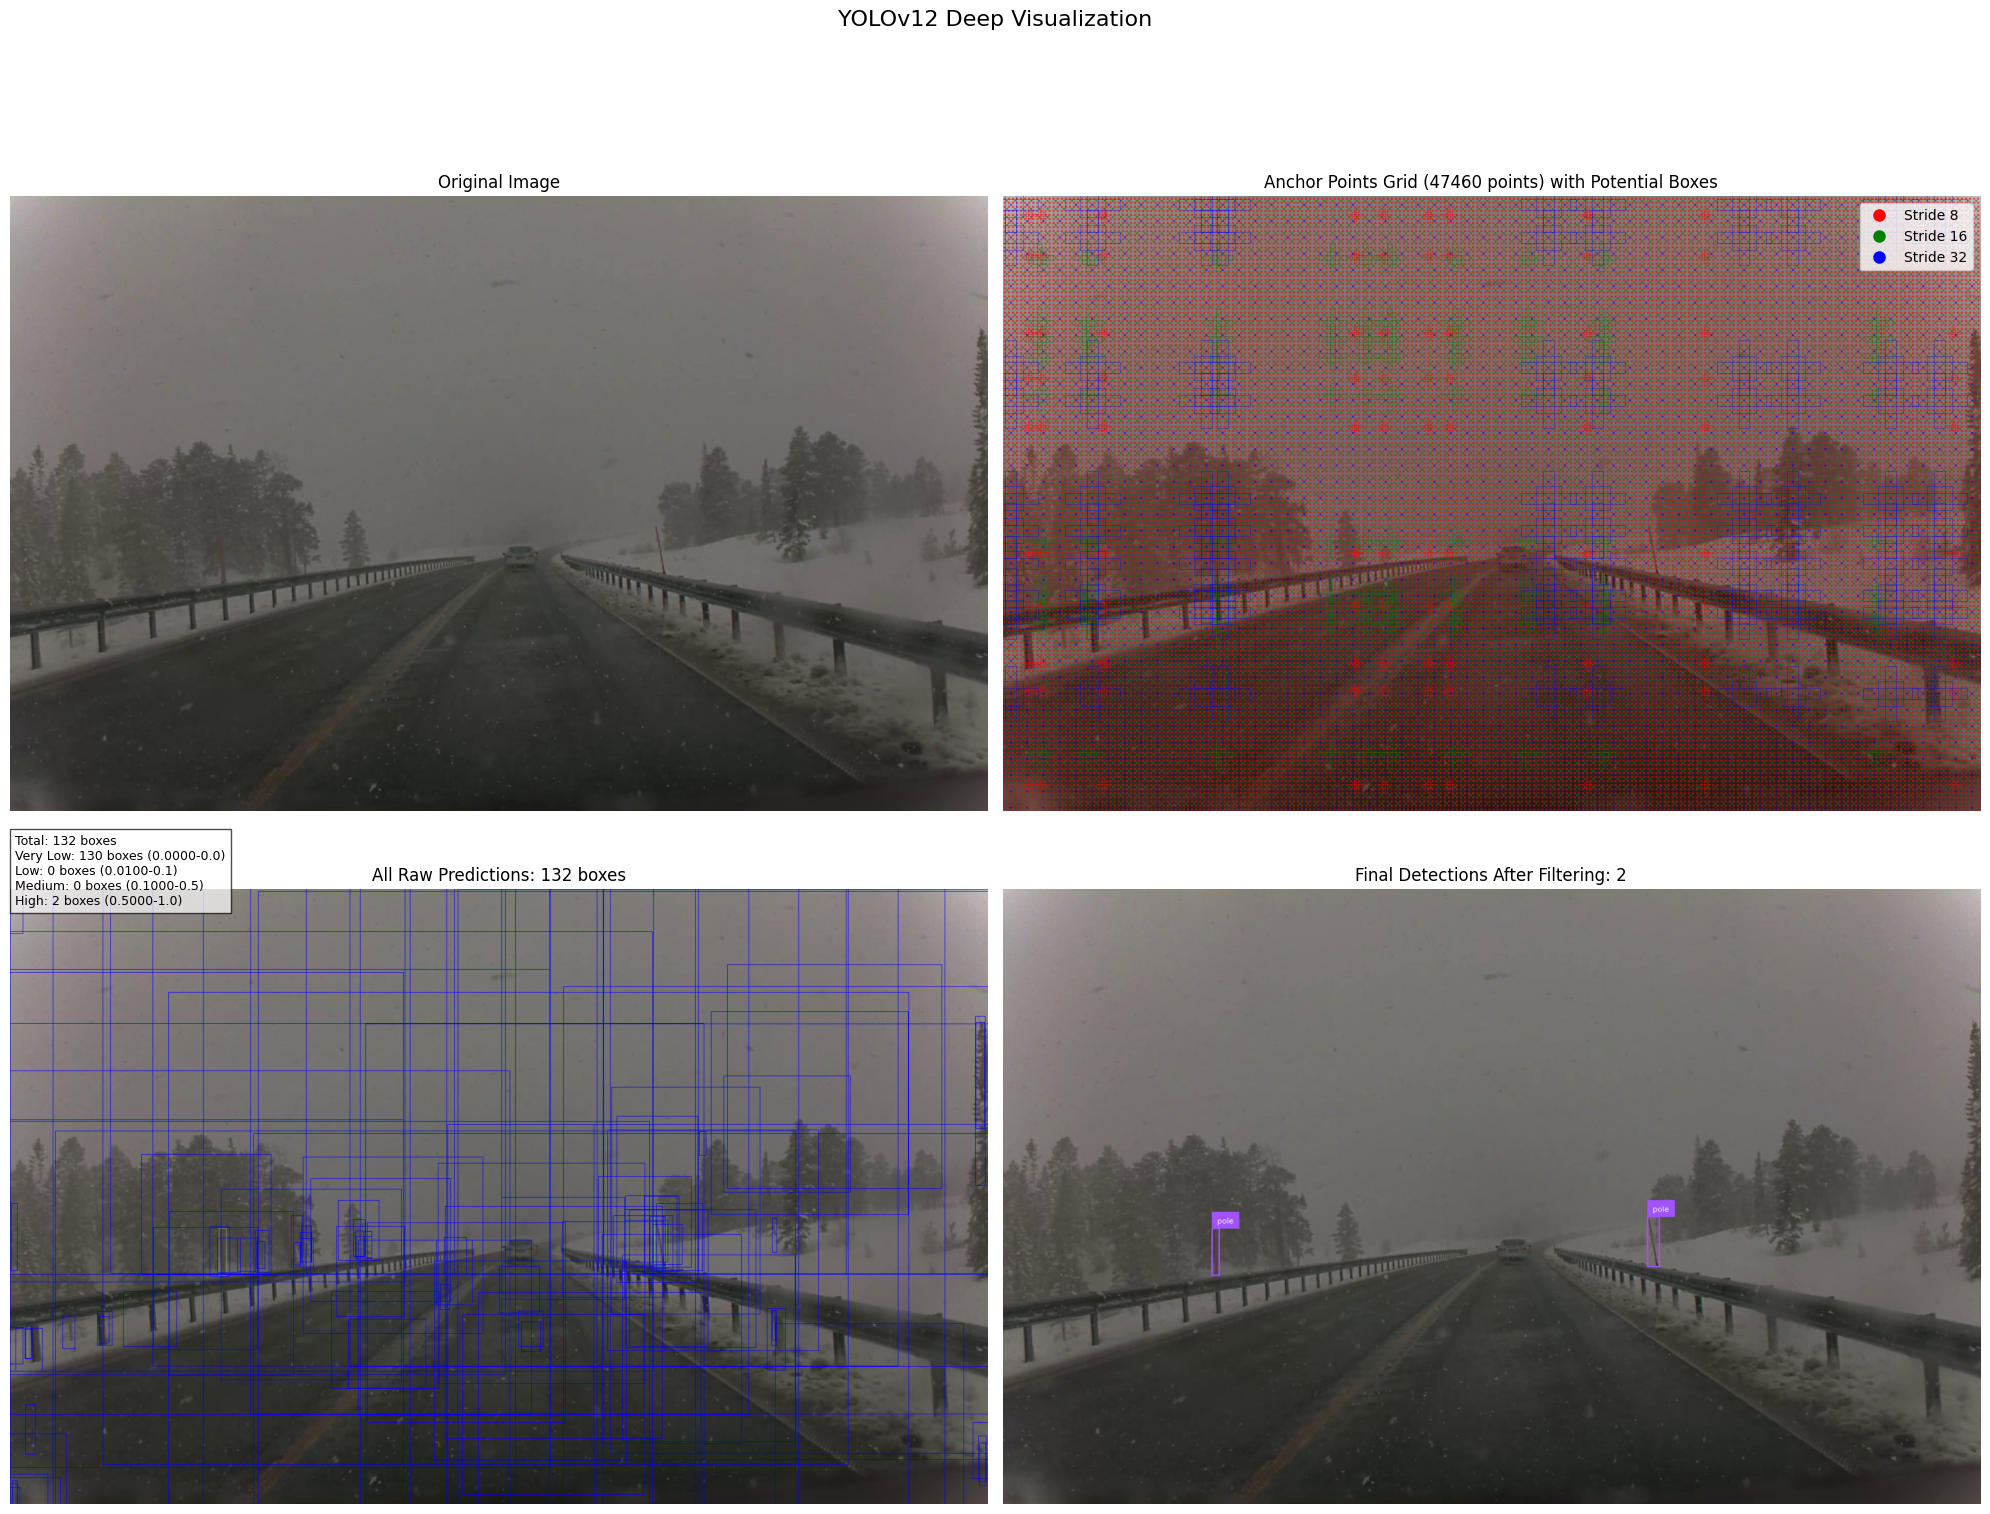

Found 132 candidate boxes total
Visualization saved to /home/omtalmo/Olaf_TTK4265/TDT4265-Snow-pole-detection/results
Total potential boxes: 47460
Actual detected boxes (very low conf): 119
Final detections: 0
Image 2: Found 119 candidate boxes


In [24]:
import os
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics.utils.tal import make_anchors

def visualize_feature_maps_and_boxes(image_path, model, conf_threshold=0.00001):
    """
    Visualize YOLOv12's detection process at a lower level:
    1. Original image
    2. All potential boxes based on anchor points
    3. Feature activation maps
    
    Args:
        image_path: Path to the image
        model: YOLO model
        conf_threshold: Extremely low threshold to see all possible candidates
    """
    # Load image
    image = cv2.imread(image_path)
    original_image = image.copy()
    h, w = image.shape[:2]
    
    # Create figure with 2x2 grid
    fig, axes = plt.subplots(2, 2, figsize=(20, 16))
    fig.suptitle(f"YOLOv12 Deep Visualization", fontsize=16)
    
    # 1. Original image (top-left)
    axes[0, 0].imshow(cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB))
    axes[0, 0].set_title("Original Image")
    axes[0, 0].axis('off')
    
    # 2. Anchor points with primitive boxes (top-right)
    # Get the feature maps and stride info from the model
    stride = model.model.stride
    features = [torch.zeros(1, 3, h // int(s), w // int(s)) for s in stride]
    
    # Generate anchors similar to how YOLOv12 does internally
    anchor_points, stride_tensor = make_anchors(features, stride)
    anchor_points = anchor_points.cpu().numpy()
    
    # Plot anchor points on original image with potential boxes
    anchor_img = original_image.copy()
    axes[0, 1].imshow(cv2.cvtColor(anchor_img, cv2.COLOR_BGR2RGB))
    
    # Draw grid for each stride with different colors and sample boxes
    colors = ['red', 'green', 'blue', 'yellow', 'cyan']
    legend_elements = []
    
    # Draw sample potential boxes at each anchor point
    # These are theoretical boxes before any prediction happens
    for i, s in enumerate(stride):
        s = int(s)
        color = colors[i % len(colors)]
        
        # Create grid points for this stride
        x_points = np.arange(s//2, w, s)
        y_points = np.arange(s//2, h, s)
        
        # Sample some points to avoid overcrowding (10% of points)
        np.random.seed(42)  # For reproducibility
        sample_size = max(1, int(0.1 * len(x_points) * len(y_points)))
        x_samples = np.random.choice(x_points, min(10, len(x_points)), replace=False)
        y_samples = np.random.choice(y_points, min(10, len(y_points)), replace=False)
        
        # Draw anchor points
        for x in x_points:
            for y in y_points:
                axes[0, 1].add_patch(plt.Circle((x, y), radius=1, color=color, alpha=0.5))
                
        # Draw sample bounding boxes at selected anchor points
        # Using multiple aspect ratios to show potential boxes (thin, medium, wide)
        aspect_ratios = [0.2, 1.0, 5.0]  # width/height ratios
        
        for x in x_samples:
            for y in y_samples:
                for ratio in aspect_ratios:
                    # Size proportional to stride
                    width = s * np.sqrt(ratio) * 1.5
                    height = s / np.sqrt(ratio) * 1.5
                    
                    rect = plt.Rectangle(
                        (x - width/2, y - height/2),
                        width, height,
                        linewidth=0.5,
                        edgecolor=color,
                        facecolor='none',
                        alpha=0.4
                    )
                    axes[0, 1].add_patch(rect)
        
        legend_elements.append(plt.Line2D([0], [0], marker='o', color=color, 
                                        label=f'Stride {s}', markersize=8, linestyle='None'))
    
    axes[0, 1].legend(handles=legend_elements, loc='upper right')
    axes[0, 1].set_title(f"Anchor Points Grid ({len(anchor_points)} points) with Potential Boxes")
    axes[0, 1].axis('off')
    
    # 3. Lowest confidence predictions (bottom-left)
    # Run prediction with extremely low confidence to capture more boxes
    results_low_conf = model.predict(image_path, conf=conf_threshold, verbose=False, nms=False)
    boxes_low_conf = results_low_conf[0].boxes.data.cpu().numpy()
    
    # Draw all detected boxes from explicit prediction
    low_conf_img = original_image.copy()
    
    # Count boxes by confidence ranges
    conf_ranges = {
        'very_low': [conf_threshold, 0.01],
        'low': [0.01, 0.1],
        'medium': [0.1, 0.5], 
        'high': [0.5, 1.0]
    }
    
    box_counts = {range_name: 0 for range_name in conf_ranges}
    
    for box in boxes_low_conf:
        x1, y1, x2, y2 = map(int, box[:4])
        conf = float(box[4])
        
        # Determine confidence range
        for range_name, (min_conf, max_conf) in conf_ranges.items():
            if min_conf <= conf < max_conf:
                box_counts[range_name] += 1
                break
                
        # Color based on confidence (green to red)
        color_b = max(0, int(255 * (1-conf)))  
        color_g = max(0, int(255 * conf))
        color_r = max(0, int(255 * (0.5 - abs(conf - 0.5)) * 2))  # Peak at 0.5 conf
        
        cv2.rectangle(low_conf_img, (x1, y1), (x2, y2), (color_b, color_g, color_r), 1)
    
    axes[1, 0].imshow(cv2.cvtColor(low_conf_img, cv2.COLOR_BGR2RGB))
    
    # Create legend text for confidence ranges
    conf_text = "\n".join([
        f"{range_name.replace('_', ' ').title()}: {count} boxes ({min_conf:.4f}-{max_conf:.1f})"
        for range_name, count in box_counts.items()
        for min_conf, max_conf in [conf_ranges[range_name]]
    ])
    
    total_boxes = sum(box_counts.values())
    axes[1, 0].text(10, 30, f"Total: {total_boxes} boxes\n{conf_text}", 
                    bbox=dict(facecolor='white', alpha=0.7), fontsize=9)
    
    axes[1, 0].set_title(f"All Raw Predictions: {len(boxes_low_conf)} boxes")
    axes[1, 0].axis('off')
    
    # 4. Final filtered predictions (bottom-right)
    results = model.predict(image_path, conf=0.25, verbose=False)  # Standard filtering
    detections = sv.Detections.from_ultralytics(results[0])
    
    # Draw final boxes
    final_img = original_image.copy()
    final_img = bounding_box_annotator.annotate(scene=final_img, detections=detections)
    final_img = label_annotator.annotate(scene=final_img, detections=detections)
    
    axes[1, 1].imshow(cv2.cvtColor(final_img, cv2.COLOR_BGR2RGB))
    axes[1, 1].set_title(f"Final Detections After Filtering: {len(detections)}")
    axes[1, 1].axis('off')
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    
    # Save the visualization
    image_filename = Path(image_path).name
    fig_path = os.path.join(output_dir, f"deep_vis_{image_filename.split('.')[0]}.png")
    fig.savefig(fig_path, bbox_inches='tight')
    
    print(f"Total potential boxes: {len(anchor_points)}")
    print(f"Actual detected boxes (very low conf): {total_boxes}")
    print(f"Final detections: {len(detections)}")
    
    return fig, total_boxes

# Run visualization with extremely low confidence to see more boxes
example_image_path = test_images[0]
fig, box_count = visualize_feature_maps_and_boxes(example_image_path, model, conf_threshold=0.00001)
plt.show()

print(f"Found {box_count} candidate boxes total")
print(f"Visualization saved to {output_dir}")

# Try with one more image
if len(test_images) > 1:
    fig, count = visualize_feature_maps_and_boxes(test_images[1], model, conf_threshold=0.00001)
    print(f"Image 2: Found {count} candidate boxes")
    plt.close(fig)

### Aspect ration analysis for 1 image

Getting predictions with very low confidence threshold...

=== Bounding Box Aspect Ratio Analysis ===
Total boxes analyzed: 132

Category distribution:
  very_tall: 29 boxes (22.0%) - AR range: 0.00 to 0.33
  tall: 24 boxes (18.2%) - AR range: 0.33 to 0.67
  square: 32 boxes (24.2%) - AR range: 0.90 to 1.10
  slightly_tall: 16 boxes (12.1%) - AR range: 0.67 to 0.90
  wide: 8 boxes (6.1%) - AR range: 1.50 to 3.00
  slightly_wide: 23 boxes (17.4%) - AR range: 1.10 to 1.50

Statistical summary:
  Mean aspect ratio: 0.81
  Median aspect ratio: 0.84
  Standard deviation: 0.46
  Min aspect ratio: 0.06
  Max aspect ratio: 1.98


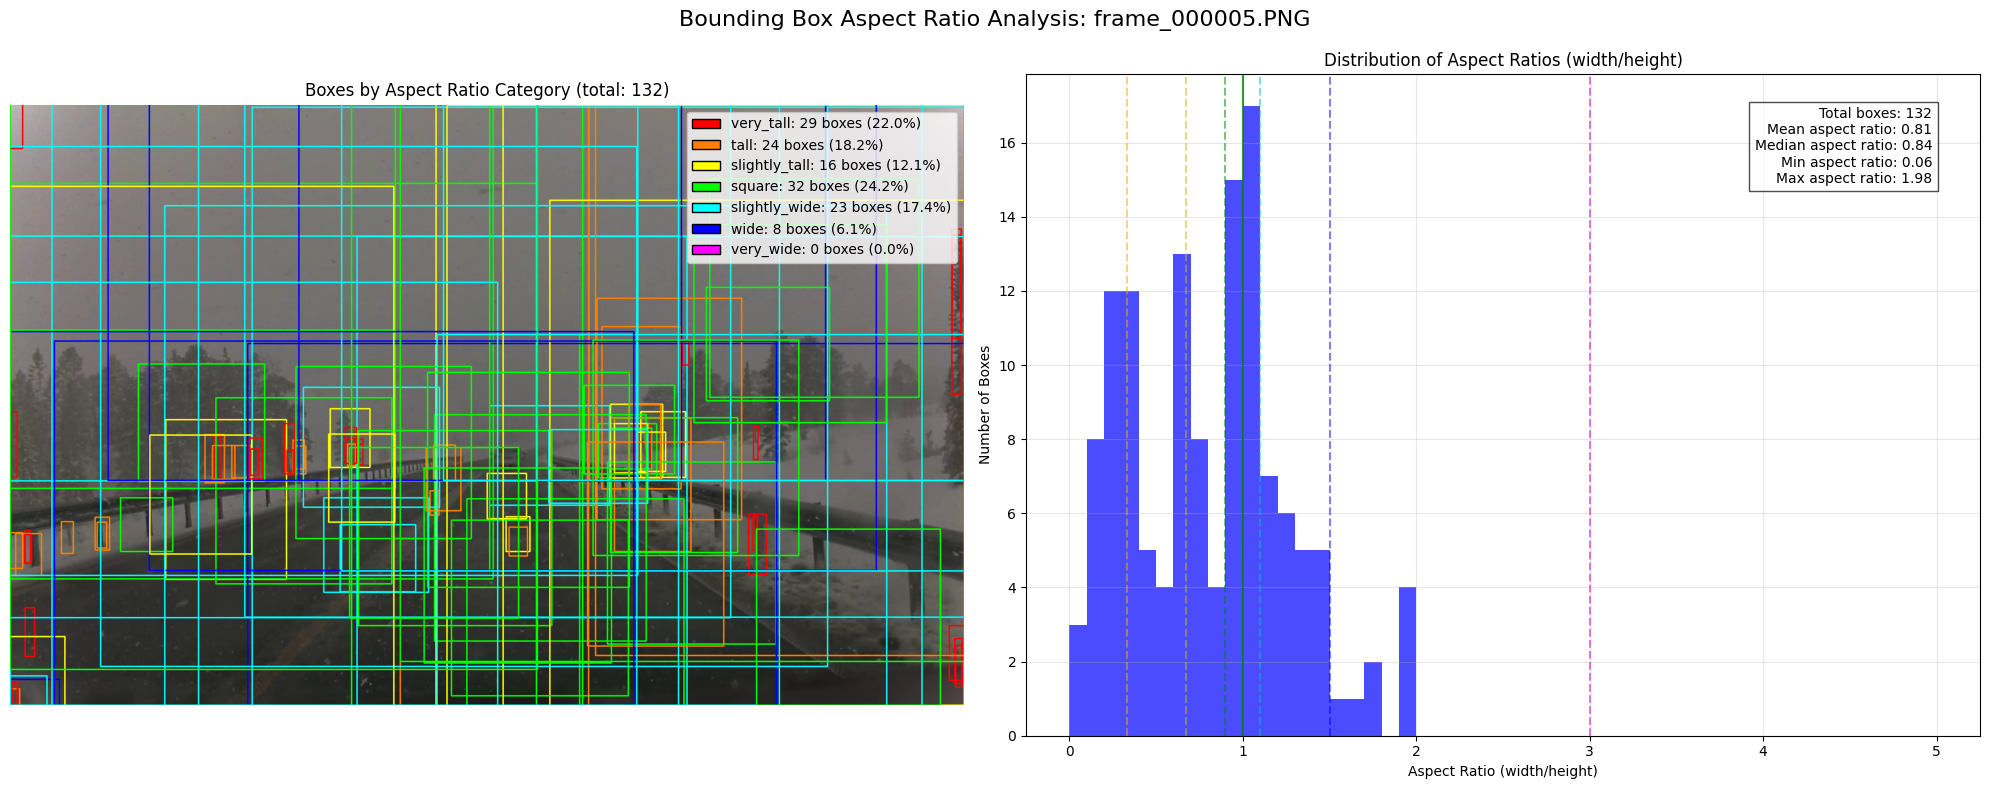

Getting predictions with very low confidence threshold...

=== Bounding Box Aspect Ratio Analysis ===
Total boxes analyzed: 119

Category distribution:
  very_tall: 28 boxes (23.5%) - AR range: 0.00 to 0.33
  tall: 21 boxes (17.6%) - AR range: 0.33 to 0.67
  square: 21 boxes (17.6%) - AR range: 0.90 to 1.10
  slightly_tall: 18 boxes (15.1%) - AR range: 0.67 to 0.90
  slightly_wide: 18 boxes (15.1%) - AR range: 1.10 to 1.50
  wide: 13 boxes (10.9%) - AR range: 1.50 to 3.00

Statistical summary:
  Mean aspect ratio: 0.82
  Median aspect ratio: 0.80
  Standard deviation: 0.51
  Min aspect ratio: 0.08
  Max aspect ratio: 2.94


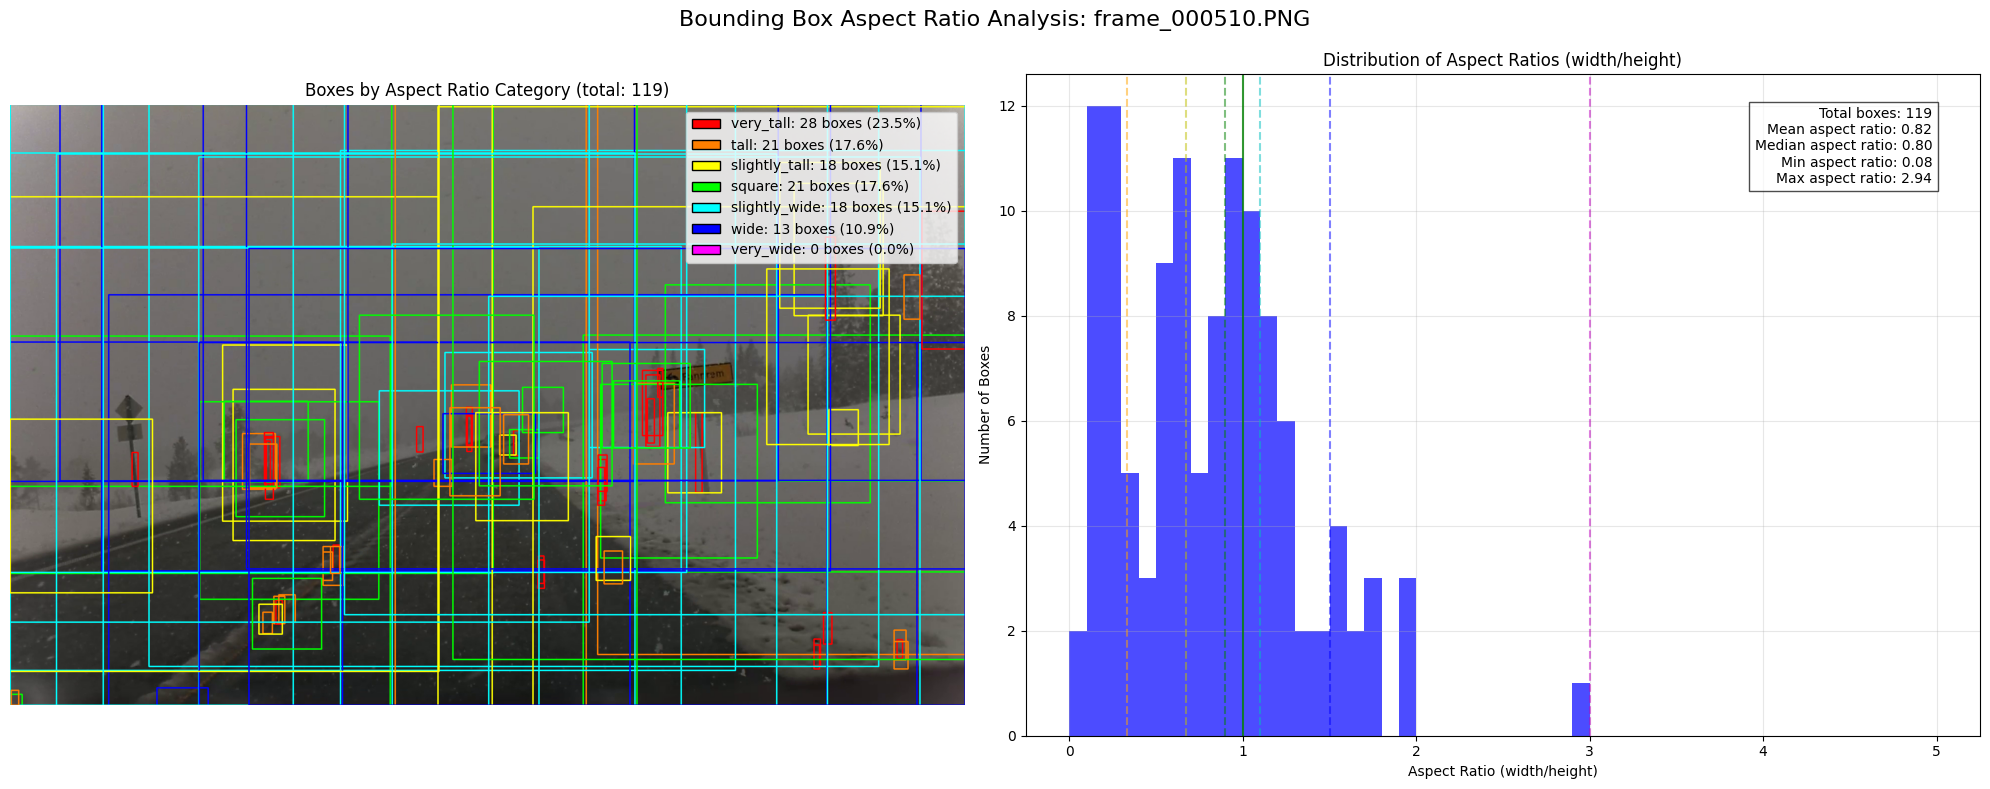

In [25]:
import os
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict

def analyze_box_aspect_ratios(image_path, model, conf_threshold=0.00001):
    """
    Analyze and visualize aspect ratios of the detected bounding boxes.
    
    Args:
        image_path: Path to the image
        model: YOLO model
        conf_threshold: Threshold for box detection
    """
    # Load image
    image = cv2.imread(image_path)
    original_image = image.copy()
    h, w = image.shape[:2]
    
    # Run prediction with extremely low confidence to capture all boxes
    print("Getting predictions with very low confidence threshold...")
    results_low_conf = model.predict(image_path, conf=conf_threshold, verbose=False, nms=False)
    boxes_low_conf = results_low_conf[0].boxes.data.cpu().numpy()
    
    # Calculate aspect ratios for all boxes
    aspect_ratios = []
    for box in boxes_low_conf:
        x1, y1, x2, y2 = map(int, box[:4])
        width = x2 - x1
        height = y2 - y1
        # Avoid division by zero
        if height == 0:
            continue
        aspect_ratio = width / height
        aspect_ratios.append(aspect_ratio)
    
    # Define aspect ratio categories
    categories = {
        'very_tall': (0, 0.33),     # height is 3x+ width
        'tall': (0.33, 0.67),       # height is 1.5x to 3x width
        'slightly_tall': (0.67, 0.9), # height slightly larger than width
        'square': (0.9, 1.1),       # roughly square
        'slightly_wide': (1.1, 1.5), # width slightly larger than height
        'wide': (1.5, 3.0),        # width is 1.5x to 3x height
        'very_wide': (3.0, float('inf')) # width is 3x+ height
    }
    
    # Categorize boxes
    categorized = defaultdict(list)
    for ar in aspect_ratios:
        for category, (min_ar, max_ar) in categories.items():
            if min_ar <= ar < max_ar:
                categorized[category].append(ar)
                break
    
    # Count categories
    category_counts = {category: len(boxes) for category, boxes in categorized.items()}
    total_boxes = len(aspect_ratios)
    
    # Create figure for visualization
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    fig.suptitle(f"Bounding Box Aspect Ratio Analysis: {Path(image_path).name}", fontsize=16)
    
    # 1. Original image with all bounding boxes colored by aspect ratio
    # Create a copy of the original image
    aspect_ratio_image = original_image.copy()
    
    # Color mapping for categories
    color_map = {
        'very_tall': (0, 0, 255),     # Red
        'tall': (0, 127, 255),         # Orange
        'slightly_tall': (0, 255, 255), # Yellow
        'square': (0, 255, 0),         # Green
        'slightly_wide': (255, 255, 0), # Cyan
        'wide': (255, 0, 0),           # Blue
        'very_wide': (255, 0, 255)      # Magenta
    }
    
    # Draw boxes with category-based coloring
    for box in boxes_low_conf:
        x1, y1, x2, y2 = map(int, box[:4])
        width = x2 - x1
        height = y2 - y1
        
        # Avoid division by zero
        if height == 0:
            continue
            
        aspect_ratio = width / height
        
        # Determine category
        box_category = None
        for category, (min_ar, max_ar) in categories.items():
            if min_ar <= aspect_ratio < max_ar:
                box_category = category
                break
                
        # Get color based on category
        color = color_map.get(box_category, (255, 255, 255))
        
        # Draw rectangle
        cv2.rectangle(aspect_ratio_image, (x1, y1), (x2, y2), color, 2)
    
    # Display image
    axes[0].imshow(cv2.cvtColor(aspect_ratio_image, cv2.COLOR_BGR2RGB))
    axes[0].set_title(f"Boxes by Aspect Ratio Category (total: {total_boxes})")
    axes[0].axis('off')
    
    # Create legend for categories
    legend_elements = []
    for category, color in color_map.items():
        # Convert BGR to RGB for matplotlib
        color_rgb = (color[2]/255, color[1]/255, color[0]/255)
        count = len(categorized[category])
        percentage = (count / total_boxes * 100) if total_boxes > 0 else 0
        
        # Create patch for legend
        patch = plt.Rectangle((0, 0), 1, 1, facecolor=color_rgb, edgecolor='black')
        legend_elements.append((patch, f"{category}: {count} boxes ({percentage:.1f}%)"))
    
    # Add legend to first subplot
    legend_patches = [item[0] for item in legend_elements]
    legend_labels = [item[1] for item in legend_elements]
    axes[0].legend(legend_patches, legend_labels, loc='upper right')
    
    # 2. Histogram of aspect ratios
    axes[1].hist(aspect_ratios, bins=50, range=(0, 5), alpha=0.7, color='blue')
    axes[1].set_title(f"Distribution of Aspect Ratios (width/height)")
    axes[1].set_xlabel("Aspect Ratio (width/height)")
    axes[1].set_ylabel("Number of Boxes")
    axes[1].grid(alpha=0.3)
    
    # Add vertical lines for category boundaries
    colors = ['r', 'orange', 'y', 'g', 'c', 'b', 'm']
    for i, (category, (min_val, max_val)) in enumerate(categories.items()):
        if min_val > 0:
            axes[1].axvline(x=min_val, color=colors[i % len(colors)], linestyle='--', alpha=0.5)
    
    # Add vertical line at aspect ratio = 1 (square)
    axes[1].axvline(x=1.0, color='g', linestyle='-', alpha=0.8, label="Square (AR=1)")
    
    # Add text showing statistics
    stats_text = "\n".join([
        f"Total boxes: {total_boxes}",
        f"Mean aspect ratio: {np.mean(aspect_ratios):.2f}",
        f"Median aspect ratio: {np.median(aspect_ratios):.2f}",
        f"Min aspect ratio: {min(aspect_ratios):.2f}",
        f"Max aspect ratio: {max(aspect_ratios):.2f}"
    ])
    axes[1].text(0.95, 0.95, stats_text, 
                transform=axes[1].transAxes, 
                fontsize=10, 
                bbox=dict(facecolor='white', alpha=0.7),
                verticalalignment='top', 
                horizontalalignment='right')
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    
    # Save the visualization
    image_filename = Path(image_path).name
    fig_path = os.path.join(output_dir, f"aspect_ratio_analysis_{image_filename.split('.')[0]}.png")
    fig.savefig(fig_path, bbox_inches='tight')
    
    # Print summary statistics
    print("\n=== Bounding Box Aspect Ratio Analysis ===")
    print(f"Total boxes analyzed: {total_boxes}")
    print("\nCategory distribution:")
    for category, count in category_counts.items():
        percentage = (count / total_boxes * 100) if total_boxes > 0 else 0
        min_val, max_val = categories[category]
        print(f"  {category}: {count} boxes ({percentage:.1f}%) - AR range: {min_val:.2f} to {max_val:.2f}")
    
    print("\nStatistical summary:")
    print(f"  Mean aspect ratio: {np.mean(aspect_ratios):.2f}")
    print(f"  Median aspect ratio: {np.median(aspect_ratios):.2f}")
    print(f"  Standard deviation: {np.std(aspect_ratios):.2f}")
    print(f"  Min aspect ratio: {min(aspect_ratios):.2f}")
    print(f"  Max aspect ratio: {max(aspect_ratios):.2f}")
    
    return aspect_ratios, categorized, fig

# Run the aspect ratio analysis
example_image_path = test_images[0]
aspect_ratios, categorized_boxes, fig = analyze_box_aspect_ratios(example_image_path, model, conf_threshold=0.00001)
plt.show()

# Try with one more image if available
if len(test_images) > 1:
    aspect_ratios2, categorized_boxes2, fig2 = analyze_box_aspect_ratios(test_images[1], model, conf_threshold=0.00001)
    plt.show()

### Aspect ratio analysis for labels (ground truth)

Found 414 label files

=== Ground Truth Bounding Box Aspect Ratio Analysis ===
Total boxes analyzed: 505

Category distribution:
  very_tall: 505 boxes (100.0%) - AR range: 0.00 to 0.33

Statistical summary:
  Mean aspect ratio: 0.07
  Median aspect ratio: 0.07
  Standard deviation: 0.04
  Min aspect ratio: 0.02
  Max aspect ratio: 0.25

Visualization saved to /home/omtalmo/Olaf_TTK4265/TDT4265-Snow-pole-detection/results/ground_truth_aspect_ratio_analysis.png


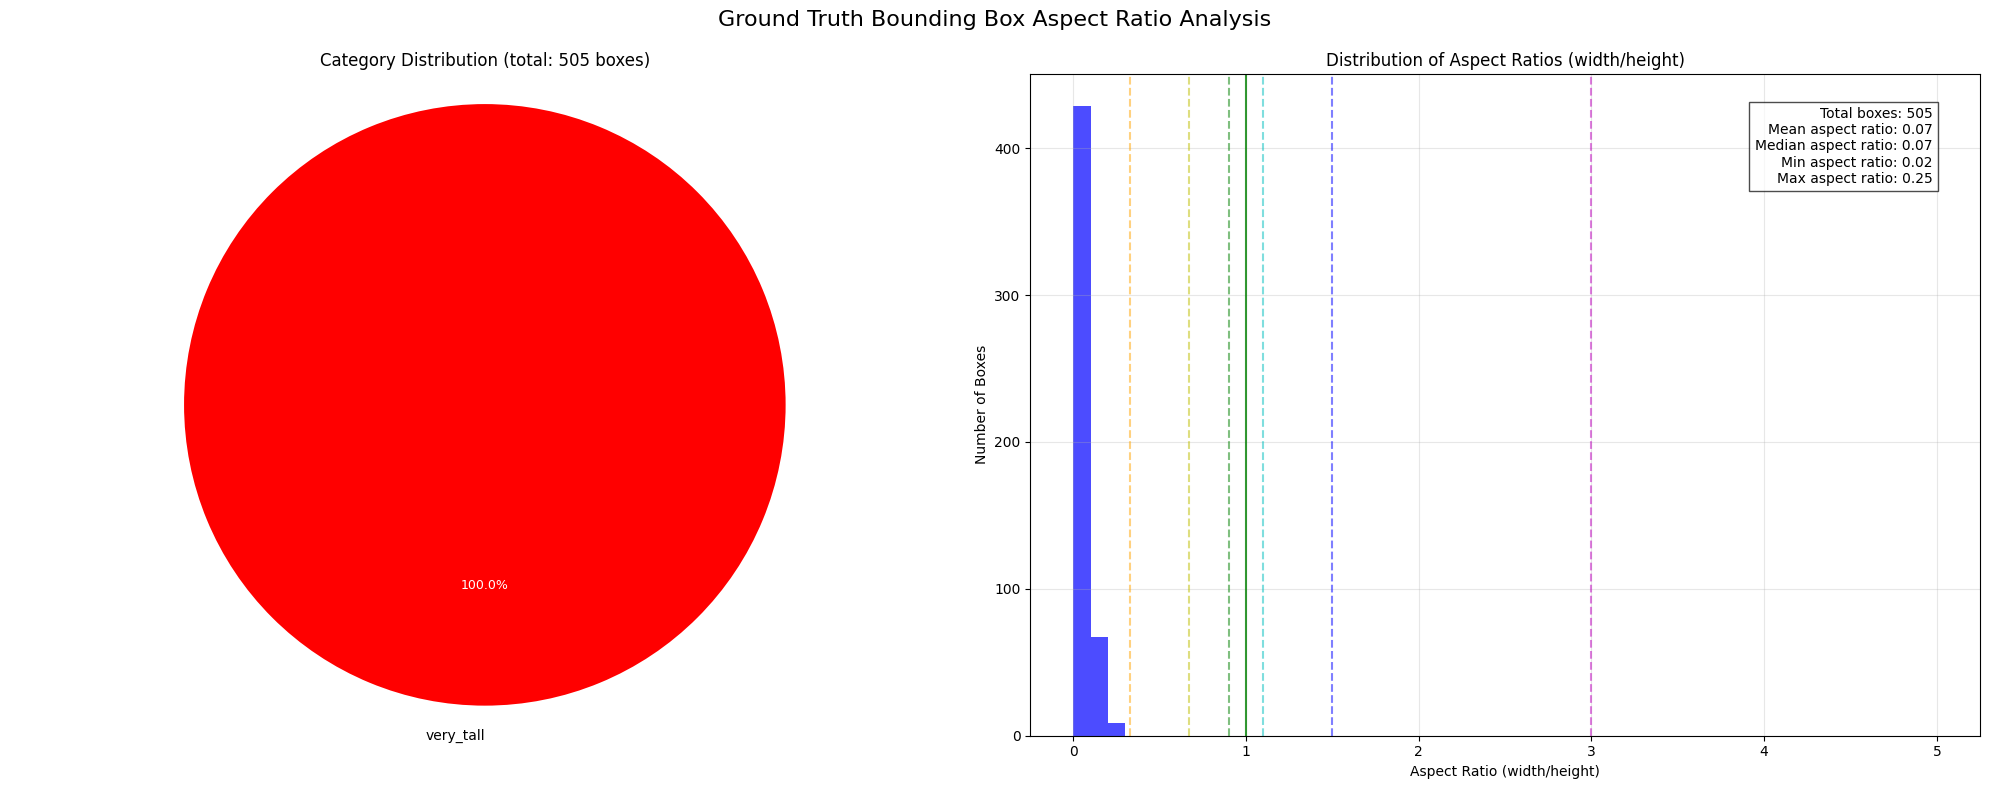

In [17]:
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict

# Path to your dataset
dataset_path = "/home/omtalmo/Olaf_TTK4265/Poles/rgb"
labels_dir = os.path.join(dataset_path, "labels")

def analyze_ground_truth_aspect_ratios():
    """
    Analyze aspect ratios of ground truth bounding boxes from label files.
    YOLO format labels: [class_id, x_center, y_center, width, height] (normalized)
    """
    # Collect all label files from train and valid directories
    all_label_files = []
    
    for split in ["train", "valid"]:
        split_dir = os.path.join(labels_dir, split)
        if os.path.exists(split_dir):
            label_files = [os.path.join(split_dir, f) for f in os.listdir(split_dir) if f.endswith('.txt')]
            all_label_files.extend(label_files)
    
    print(f"Found {len(all_label_files)} label files")
    
    # Extract aspect ratios from all files
    aspect_ratios = []
    
    for label_file in all_label_files:
        try:
            with open(label_file, 'r') as f:
                lines = f.readlines()
                
            for line in lines:
                parts = line.strip().split()
                if len(parts) == 5:  # YOLO format: class x_center y_center width height
                    # Extract normalized width and height
                    width = float(parts[3])
                    height = float(parts[4])
                    
                    if height > 0:  # Avoid division by zero
                        aspect_ratio = width / height
                        aspect_ratios.append(aspect_ratio)
        except Exception as e:
            print(f"Error processing {label_file}: {e}")
    
    # Define aspect ratio categories
    categories = {
        'very_tall': (0, 0.33),     # height is 3x+ width
        'tall': (0.33, 0.67),       # height is 1.5x to 3x width
        'slightly_tall': (0.67, 0.9), # height slightly larger than width
        'square': (0.9, 1.1),       # roughly square
        'slightly_wide': (1.1, 1.5), # width slightly larger than height
        'wide': (1.5, 3.0),        # width is 1.5x to 3x height
        'very_wide': (3.0, float('inf')) # width is 3x+ height
    }
    
    # Categorize boxes
    categorized = defaultdict(list)
    for ar in aspect_ratios:
        for category, (min_ar, max_ar) in categories.items():
            if min_ar <= ar < max_ar:
                categorized[category].append(ar)
                break
    
    # Count categories
    category_counts = {category: len(boxes) for category, boxes in categorized.items()}
    total_boxes = len(aspect_ratios)
    
    # Create visualization
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    fig.suptitle(f"Ground Truth Bounding Box Aspect Ratio Analysis", fontsize=16)
    
    # 1. Pie chart of category distribution
    # Filter out categories with zero count
    non_empty_categories = {k: v for k, v in category_counts.items() if v > 0}
    
    if non_empty_categories:
        labels = non_empty_categories.keys()
        sizes = non_empty_categories.values()
        
        # Custom colors for each category
        colors = ['red', 'orangered', 'gold', 'green', 'cyan', 'blue', 'magenta']
        
        # Create pie chart
        patches, texts, autotexts = axes[0].pie(sizes, labels=labels, autopct='%1.1f%%',
                                                colors=colors, startangle=90)
        axes[0].axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle
        
        # Make labels more readable
        for text in texts:
            text.set_fontsize(10)
        for autotext in autotexts:
            autotext.set_fontsize(9)
            autotext.set_color('white')
        
        axes[0].set_title(f"Category Distribution (total: {total_boxes} boxes)")
    else:
        axes[0].text(0.5, 0.5, "No boxes found", horizontalalignment='center',
                     verticalalignment='center', transform=axes[0].transAxes)
    
    # 2. Histogram of aspect ratios
    if aspect_ratios:
        axes[1].hist(aspect_ratios, bins=50, range=(0, 5), alpha=0.7, color='blue')
        axes[1].set_title(f"Distribution of Aspect Ratios (width/height)")
        axes[1].set_xlabel("Aspect Ratio (width/height)")
        axes[1].set_ylabel("Number of Boxes")
        axes[1].grid(alpha=0.3)
        
        # Add vertical lines for category boundaries
        colors = ['r', 'orange', 'y', 'g', 'c', 'b', 'm']
        for i, (category, (min_val, max_val)) in enumerate(categories.items()):
            if min_val > 0:
                axes[1].axvline(x=min_val, color=colors[i % len(colors)], linestyle='--', alpha=0.5)
        
        # Add vertical line at aspect ratio = 1 (square)
        axes[1].axvline(x=1.0, color='g', linestyle='-', alpha=0.8)
        
        # Add text showing statistics
        stats_text = "\n".join([
            f"Total boxes: {total_boxes}",
            f"Mean aspect ratio: {np.mean(aspect_ratios):.2f}",
            f"Median aspect ratio: {np.median(aspect_ratios):.2f}",
            f"Min aspect ratio: {min(aspect_ratios):.2f}",
            f"Max aspect ratio: {max(aspect_ratios):.2f}"
        ])
        axes[1].text(0.95, 0.95, stats_text, 
                   transform=axes[1].transAxes, 
                   fontsize=10, 
                   bbox=dict(facecolor='white', alpha=0.7),
                   verticalalignment='top', 
                   horizontalalignment='right')
    else:
        axes[1].text(0.5, 0.5, "No boxes found", horizontalalignment='center',
                     verticalalignment='center', transform=axes[1].transAxes)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    
    # Save the visualization
    output_dir = "/home/omtalmo/Olaf_TTK4265/TDT4265-Snow-pole-detection/results"
    os.makedirs(output_dir, exist_ok=True)
    fig_path = os.path.join(output_dir, "ground_truth_aspect_ratio_analysis.png")
    fig.savefig(fig_path, bbox_inches='tight')
    
    # Print summary statistics
    print("\n=== Ground Truth Bounding Box Aspect Ratio Analysis ===")
    print(f"Total boxes analyzed: {total_boxes}")
    print("\nCategory distribution:")
    for category, count in category_counts.items():
        percentage = (count / total_boxes * 100) if total_boxes > 0 else 0
        min_val, max_val = categories[category]
        print(f"  {category}: {count} boxes ({percentage:.1f}%) - AR range: {min_val:.2f} to {max_val:.2f}")
    
    if aspect_ratios:
        print("\nStatistical summary:")
        print(f"  Mean aspect ratio: {np.mean(aspect_ratios):.2f}")
        print(f"  Median aspect ratio: {np.median(aspect_ratios):.2f}")
        print(f"  Standard deviation: {np.std(aspect_ratios):.2f}")
        print(f"  Min aspect ratio: {min(aspect_ratios):.2f}")
        print(f"  Max aspect ratio: {max(aspect_ratios):.2f}")
    
    print(f"\nVisualization saved to {fig_path}")
    plt.show()
    
    return aspect_ratios, categorized, fig

# Run the analysis
aspect_ratios, categorized, fig = analyze_ground_truth_aspect_ratios()